E-Commerce Sales & Profit Analysis

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load DataseT

In [22]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
df.shape

(9994, 21)

In [25]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [26]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [28]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [29]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# Convert to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])



In [32]:
# Create new features
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

Basic Analysis

In [33]:
# Total records
print("Total Records:", len(df))

Total Records: 9994


In [34]:
# Total customers
print("Total Customers:", df['Customer ID'].nunique())

Total Customers: 793


In [35]:
#  Total sales
print("Total Sales: $", round(df['Sales'].sum(), 2))

Total Sales: $ 2297200.86


In [36]:
# Total profit
print("Total Profit: $", round(df['Profit'].sum(), 2))

Total Profit: $ 286397.02


In [37]:
# Average order value
print("Average Order Value: $", round(df.groupby('Order ID')['Sales'].sum().mean(), 2))


Average Order Value: $ 458.61


In [38]:
# Highest sales (category)
print("Highest Sales Category:", df.groupby('Category')['Sales'].sum().idxmax())

Highest Sales Category: Technology


In [39]:
# Highest sales (Region)
print("Highest Sales Region:", df.groupby('Region')['Sales'].sum().idxmax())

Highest Sales Region: West


In [40]:
# Highest sales (segment)
print("Highest Sales Segment:", df.groupby('Segment')['Sales'].sum().idxmax())

Highest Sales Segment: Consumer


Sales Analysis

In [41]:
#Top 10 products by sales
print("Top 10 Products by Sales:\n", df.groupby('Product Name')['Sales'].sum().nlargest(10))





Top 10 Products by Sales:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [42]:
# The bottom 10 products by sales
print("Bottom 10 Products by Sales:\n", df.groupby('Product Name')['Sales'].sum().nsmallest(10))



Bottom 10 Products by Sales:
 Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Newell 308                                                          8.400
Name: Sales, dtype: float64


In [43]:
#The highest profit (Category)
print("Highest Profit Category:", df.groupby('Category')['Profit'].sum().idxmax())




Highest Profit Category: Technology


In [44]:
#The highest profit(Region)
print("Highest Profit Region:", df.groupby('Region')['Profit'].sum().idxmax())





Highest Profit Region: West


In [45]:
#The highest sales (Year)
print("Highest Sales Year:", df.groupby('Year')['Sales'].sum().idxmax())



Highest Sales Year: 2017


In [46]:
#The highest sales (Month)
print("Highest Sales Month:", df.groupby('Month')['Sales'].sum().idxmax())

Highest Sales Month: November


In [47]:
#The most sales (Customers)
print("Top 5 Customers by Sales:\n", df.groupby('Customer Name')['Sales'].sum().nlargest(5))

Top 5 Customers by Sales:
 Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


In [48]:
#The highest sales (Top5 sate)
print("Top 5 States by Sales:\n", df.groupby('State')['Sales'].sum().nlargest(5))

Top 5 States by Sales:
 State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [49]:
#The average shipping time
print("Average Shipping Time:", round(df['Shipping Time'].mean(), 2), "days")

Average Shipping Time: 3.96 days


In [50]:
#Shipping mode
print("Fastest Shipping Mode:", df.groupby('Ship Mode')['Shipping Time'].mean().idxmin())

Fastest Shipping Mode: Same Day


Discount Analysis

In [51]:
#Higher discount lower profit
correlation = df['Discount'].corr(df['Profit'])
print("Correlation between Discount and Profit:", round(correlation, 2))

Correlation between Discount and Profit: -0.22


In [52]:
#The highest profit margin
category_margin = (df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum()) * 100
print("Category Profit Margins (%):\n", round(category_margin, 2))

Category Profit Margins (%):
 Category
Furniture           2.49
Office Supplies    17.04
Technology         17.40
dtype: float64


In [53]:
#High sales but low profit
cat_perf = df.groupby('Category')[['Sales', 'Profit']].sum()
print("Category Performance:\n", cat_perf)

Category Performance:
                        Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


In [54]:
#Customer segment generates the most revenue
print("Highest Revenue Segment:", df.groupby('Segment')['Sales'].sum().idxmax())

Highest Revenue Segment: Consumer


In [55]:
#Region performance
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum()
print("Regional Performance:\n", region_perf)

Regional Performance:
                Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


In [56]:
#Management promote
print("Promote High-Profit Sub-Categories:\n", df.groupby('Sub-Category')['Profit'].sum().nlargest(5))

Promote High-Profit Sub-Categories:
 Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64


In [57]:
# products should management review
print("Loss-making Sub-Categories:\n", df.groupby('Sub-Category')['Profit'].sum().nsmallest(3))

Loss-making Sub-Categories:
 Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


Visualizations

Sales by category Visualization

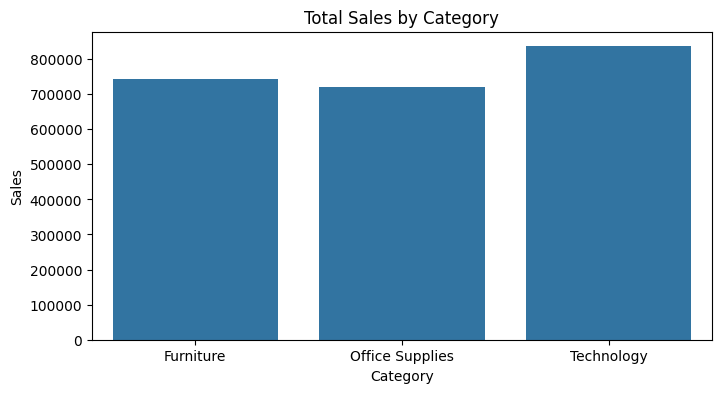

In [58]:

plt.figure(figsize=(8,4))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None)
plt.title('Total Sales by Category')
plt.show()

Total Sales by Region

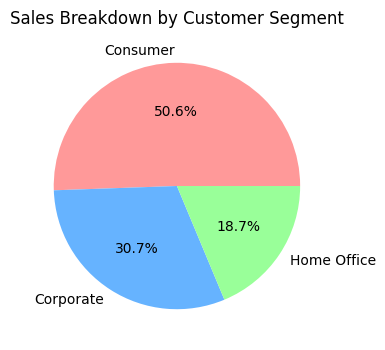

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
df.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Sales Breakdown by Customer Segment')
plt.ylabel('')
plt.show()

Monthly Sales Trend

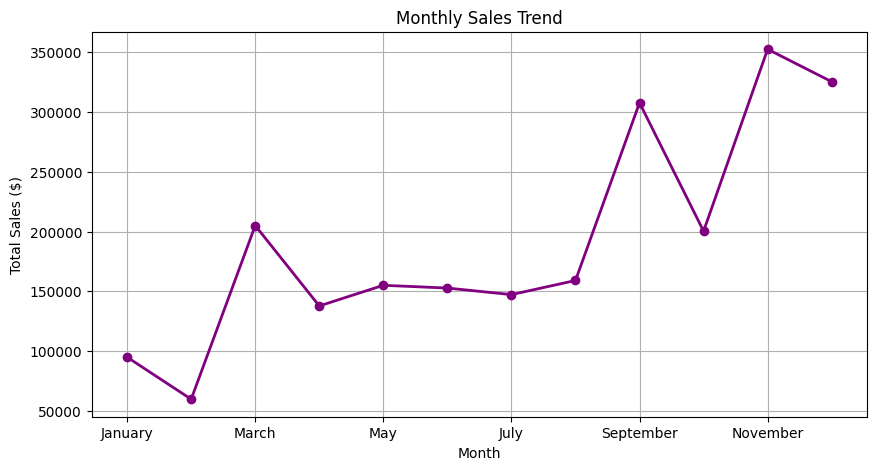

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Month')['Sales'].sum().reindex(months_order)
monthly_sales.plot(kind='line', marker='o', color='purple', linewidth=2)

plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()

Discount vs Profit Impact

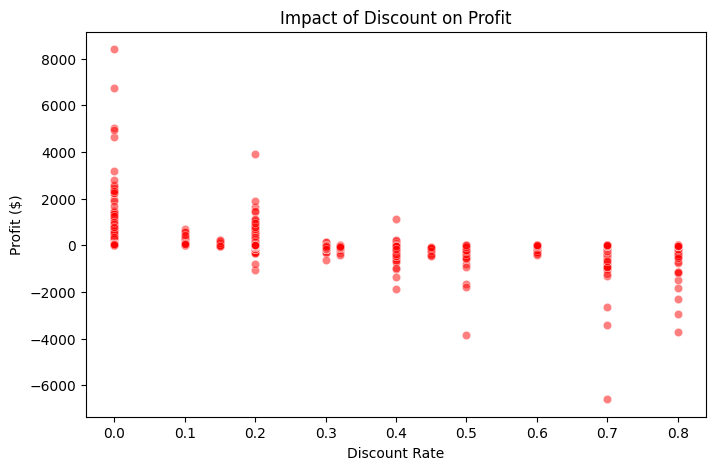

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Discount', y='Profit', data=df, color='red', alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.show()

Regional Sales Distribution

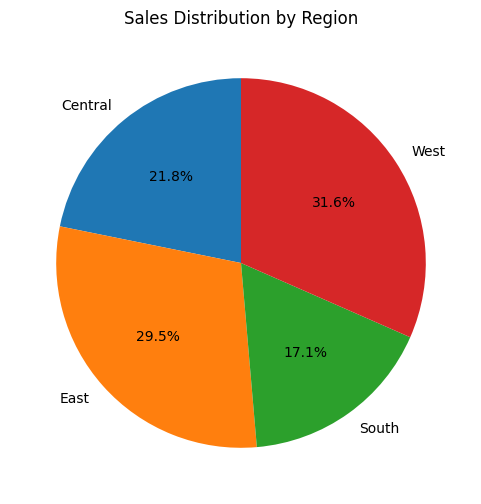

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.show()

Bottom 10 Products by Sales

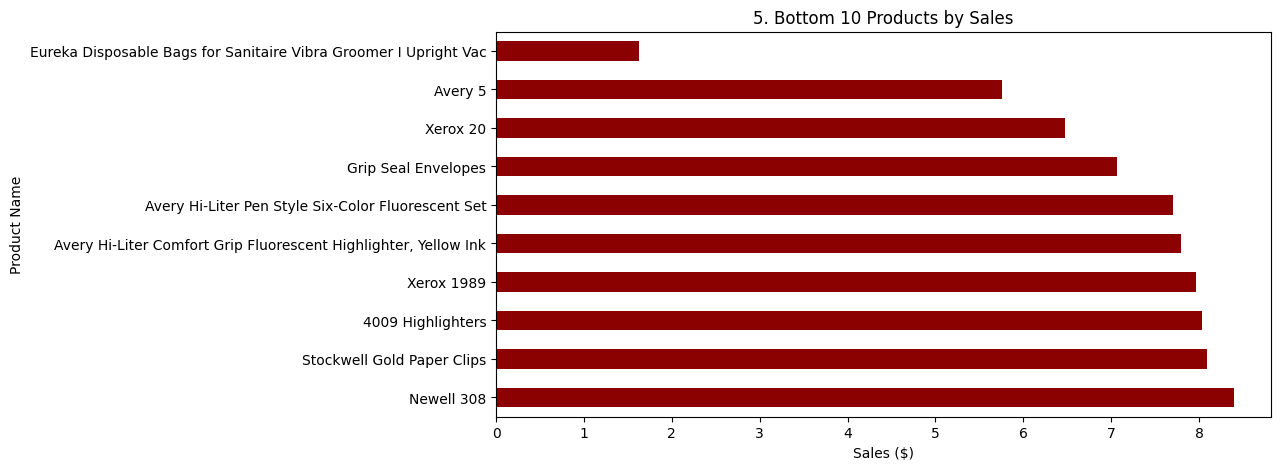

In [63]:
plt.figure(figsize=(10, 5))
df.groupby('Product Name')['Sales'].sum().nsmallest(10).plot(kind='barh', color='darkred').invert_yaxis()
plt.title('Bottom 10 Products by Sales')
plt.xlabel('Sales ($)')
plt.show()

Total Profit by Region

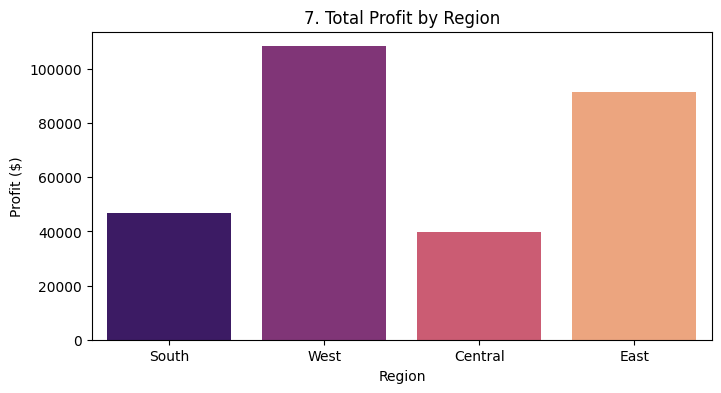

In [65]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Region', y='Profit', data=df, estimator=sum, errorbar=None, palette='magma')
plt.title('Total Profit by Region')
plt.ylabel('Profit ($)')
plt.show()

 Yearly Sales Growth Trend

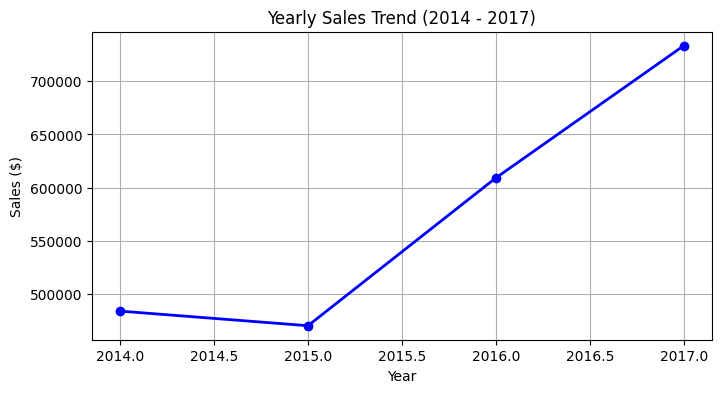

In [76]:
plt.figure(figsize=(8, 4))
df.groupby('Year')['Sales'].sum().plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Yearly Sales Trend (2014 - 2017)')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.show()

Monthly Sales Trend (Seasonality)

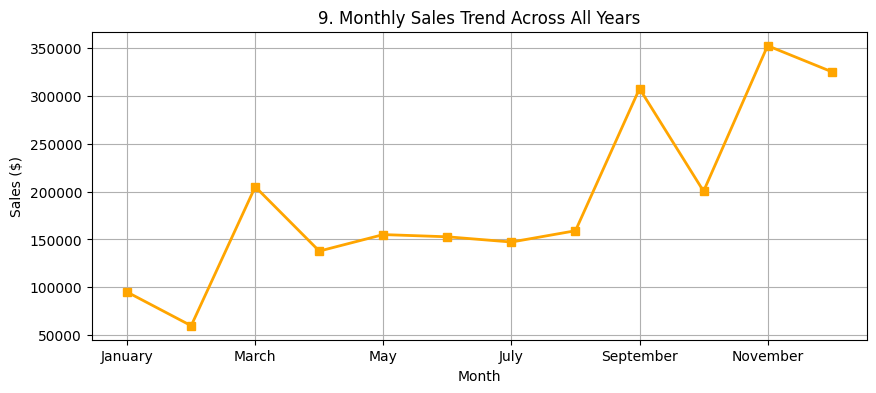

In [67]:
plt.figure(figsize=(10, 4))
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
df.groupby('Month')['Sales'].sum().reindex(months_order).plot(kind='line', marker='s', color='orange', linewidth=2)
plt.title('Monthly Sales Trend Across All Years')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.show()

Top 10 Customers by Revenue

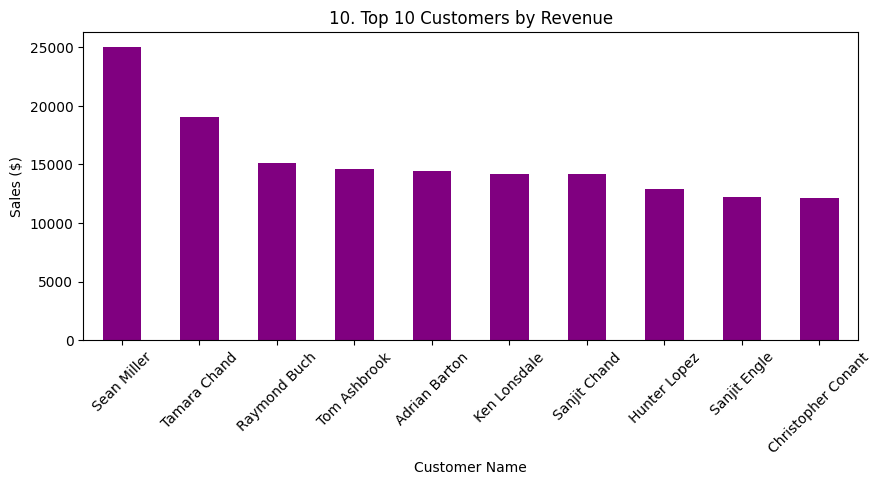

In [68]:
plt.figure(figsize=(10, 4))
df.groupby('Customer Name')['Sales'].sum().nlargest(10).plot(kind='bar', color='purple')
plt.title('Top 10 Customers by Revenue')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

Top 10 States by Sales

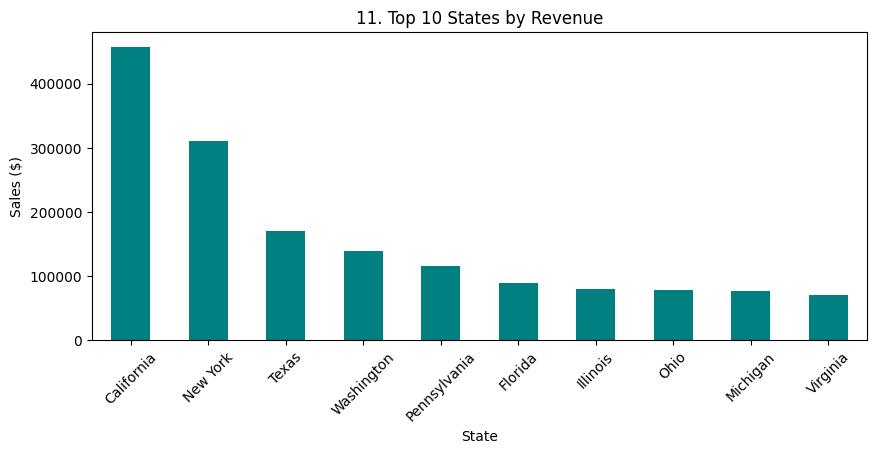

In [69]:
plt.figure(figsize=(10, 4))
df.groupby('State')['Sales'].sum().nlargest(10).plot(kind='bar', color='teal')
plt.title('Top 10 States by Revenue')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

Impact of Discount on Profitability

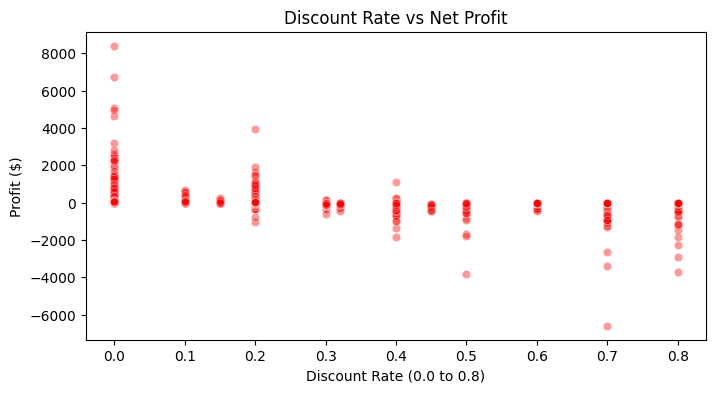

In [71]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Discount', y='Profit', data=df, color='red', alpha=0.4)
plt.title('Discount Rate vs Net Profit')
plt.xlabel('Discount Rate (0.0 to 0.8)')
plt.ylabel('Profit ($)')
plt.show()

Sub-Category Profitability Breakdown

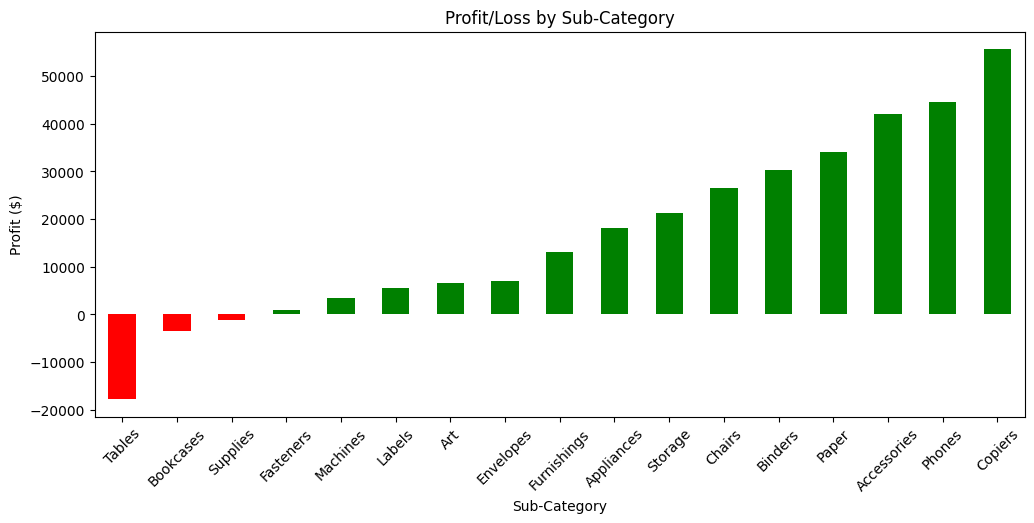

In [74]:
plt.figure(figsize=(12, 5))
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in sub_profit]
sub_profit.plot(kind='bar', color=colors)
plt.title('Profit/Loss by Sub-Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.show()

Category Profit Margin Comparison (%)

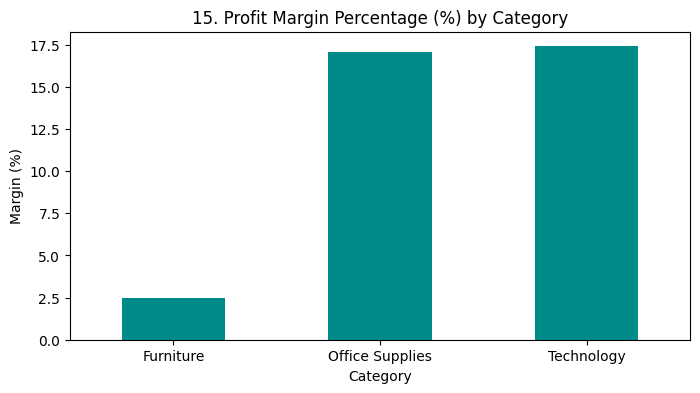

In [73]:
plt.figure(figsize=(8, 4))
cat_margins = (df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum()) * 100
cat_margins.plot(kind='bar', color='darkcyan')
plt.title('Profit Margin Percentage (%) by Category')
plt.ylabel('Margin (%)')
plt.xticks(rotation=0)
plt.show()

 Business Insights

* Insight 1 (Top Category): Technology category generates the highest sales ($836,154) and highest profit ($145,455).
* Insight 2 (Low Profit Margin): Furniture category yields high total revenue ($741,999) but severely underperforms in profitability (2.49% margin).
* Insight 3 (Loss-Making Sub-Categories): Sub-categories such as Tables (-$17,725) and Bookcases (-$3,472) are operating at a net loss.
* Insight 4 (Geographic Performance): The West Region is the company's most lucrative market ($725,458 revenue).
* Insight 5 (Discount Impact): Higher discounts negatively correlate with profitability (-0.22 correlation coefficient).

Recommendations

1. Optimize Product Pricing: Re-evaluate pricing strategies or discontinue loss-making items under the Tables and Bookcases sub-categories.
2. Cap Discounts: Limit maximum promotional discounts to 15% to prevent profit margin erosion.
3. Focus on High-Margin Products: Increase marketing focus for high-margin sub-categories like Copiers and Paper.
4. Expand Top Regions: Replicate successful sales strategies from the West region into underperforming markets like Central.

Conclusion

This project successfully analyzes the E-Commerce Superstore dataset. Technology continues to drive the highest growth and profitability for the business. By strategic restructuring of low-margin product lines like Furniture and curbing excessive discount policies, overall profitability can be significantly maximized.
